In [2]:
import importlib
from pathlib import Path
from torch.utils.data import Sampler, DataLoader, random_split
import torch
import matplotlib.pyplot as plt

In [3]:
from iminuit import Minuit

In [4]:
from functions_library import *

In [5]:
importlib.reload(model_training)

<module 'functions_library.model_training' from 'c:\\Users\\jonas\\Desktop\\Masters\\Main\\Masters_project\\functions_library\\model_training.py'>

In [59]:
notebook_dir = Path.cwd()
data_dir = notebook_dir.parent / "csv_files"
data_egam1 = np.loadtxt(data_dir / "Z_mass_EGAM1.csv", delimiter=",")
data_egam7 = np.loadtxt(data_dir / "Z_mass_EGAM7.csv", delimiter=",")
data_egamD = np.loadtxt(data_dir / "Z_mass_DataEgamma.csv", delimiter=",")
data_muon1 = np.loadtxt(data_dir / "Z_mass_MUON1.csv", delimiter=",")
data_muonD = np.loadtxt(data_dir / "Z_mass_DataMuon.csv", delimiter=",")

In [60]:
def fit_function(data, bins, function, initial_guess, limits=None):
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    sample_size = counts.sum()
    hist = counts / (sample_size * bin_widths)
    hist_errors = np.sqrt(counts) / (sample_size * bin_widths)
    fit_mask = counts > 0
    
    def chi2(*parameters):
        expected = np.asarray(
            function(bin_centers, *parameters),
            dtype=float,
        )

        valid = (
            fit_mask
            & np.isfinite(expected)
            & (expected > 0)
        )
        if not np.all(valid[fit_mask]):
            return 1e100

        residuals = (hist[valid] - expected[valid]) / hist_errors[valid]
        return np.sum(residuals ** 2)

    parameter_names = [
        f"parameter_{index}"
        for index in range(len(initial_guess))
    ]

    minimizer = Minuit(
        chi2,
        *initial_guess,
        name=parameter_names,
    )
    if limits is not None:
        minimizer.limits = limits
        
    minimizer.errordef = Minuit.LEAST_SQUARES
    minimizer.migrad(ncall=10000)

    if minimizer.fmin.is_above_max_edm or minimizer.fmin.has_reached_call_limit:
        raise RuntimeError(
            f"Minuit failed to find a minimum: {minimizer.fmin}"
        )

    return np.asarray(minimizer.values), np.asarray(minimizer.errors), minimizer.fval

In [ ]:
def gaussian(x, mean, stddev):
    return 1 / (np.sqrt(2 * np.pi) * stddev) * np.exp(
        -((x - mean) ** 2) / (2 * stddev ** 2)
    )


def crystal_ball_left(x, mean, stddev, alpha, n):
    """Crystal Ball shape with a power-law tail on the low-x side."""
    z = (x - mean) / stddev
    alpha = abs(alpha)

    A = (n / alpha) ** n * np.exp(-alpha ** 2 / 2)
    B = n / alpha - alpha
    tail_base = np.maximum(B - z, np.finfo(float).eps)

    shape = np.empty_like(z, dtype=float)
    gaussian_mask = z > -alpha
    shape[gaussian_mask] = np.exp(-z[gaussian_mask] ** 2 / 2)
    shape[~gaussian_mask] = A * tail_base[~gaussian_mask] ** (-n)

    return shape / (np.sqrt(2 * np.pi) * stddev)


def breit_wigner(x, mass, width):
    """Normalized non-relativistic Breit-Wigner distribution."""
    half_width = width / 2
    return 1 / np.pi * half_width / (
        (x - mass) ** 2 + half_width ** 2
    )

def exponential_decay(x, amplitude, decay_constant):
    """Exponential decay function."""
    return amplitude * np.exp(-decay_constant * x)

def breit_wigner_crystal_ball(
    x, amplitude, mean_bw, width_bw, sigma_cb, alpha_cb, n_cb
):
    """Breit-Wigner convolved with a low-mass Crystal Ball response."""
    x = np.asarray(x, dtype=float)
    step = 0.02
    bw_grid = np.arange(40.0, 151.0 + step, step)
    response_grid = np.arange(-110.0, 111.0 + step, step)

    bw_values = breit_wigner(bw_grid, mean_bw, width_bw)
    response_values = crystal_ball_left(
        response_grid, 0.0, sigma_cb, alpha_cb, n_cb
    )
    response_values /= np.trapezoid(response_values, response_grid)

    convolution = fftconvolve(bw_values, response_values, mode="full") * step
    convolution_grid = (
        bw_grid[0]
        + response_grid[0]
        + np.arange(convolution.size) * step
    )

    result = np.interp(x, convolution_grid, convolution, left=0.0, right=0.0)
    return amplitude * result


def crystal_ball_double(
    x, mean, stddev, alpha_left, n_left, alpha_right, n_right
):
    """Crystal Ball shape with independent low- and high-x power-law tails."""
    z = (x - mean) / stddev
    alpha_left = abs(alpha_left)
    alpha_right = abs(alpha_right)

    A_left = (n_left / alpha_left) ** n_left * np.exp(-alpha_left ** 2 / 2)
    B_left = n_left / alpha_left - alpha_left
    A_right = (n_right / alpha_right) ** n_right * np.exp(-alpha_right ** 2 / 2)
    B_right = n_right / alpha_right - alpha_right

    shape = np.empty_like(z, dtype=float)
    left_mask = z <= -alpha_left
    right_mask = z >= alpha_right
    core_mask = ~(left_mask | right_mask)

    shape[left_mask] = A_left * np.maximum(
        B_left - z[left_mask], np.finfo(float).eps
    ) ** (-n_left)
    shape[core_mask] = np.exp(-z[core_mask] ** 2 / 2)
    shape[right_mask] = A_right * np.maximum(
        B_right + z[right_mask], np.finfo(float).eps
    ) ** (-n_right)

    return shape / (np.sqrt(2 * np.pi) * stddev)


def data_fit_ratio(x, ratio):
    return (
        ratio * breit_wigner_crystal_ball(x, *vals_egam1)
        + (1 - ratio) * exponential_decay(x, *vals_egam7)
    )

def true_data_fit(x, amplitude_sig, amplitude_bkg, mean_bw, width_bw, sigma_cb, alpha_cb, n_cb, decay_constant):
    return (
        breit_wigner_crystal_ball(x, amplitude_sig, mean_bw, width_bw, sigma_cb, alpha_cb, n_cb)
        + exponential_decay(x, amplitude_bkg, decay_constant)
    )


bw_cb_limits = [
    (0.1, 10.0),
    (60.0, 120.0),
    (2.0, 4.0),
    (0.5, 10.0),
    (0.0, 4.0),
    (0.0, 20.0),
]

exp_limits = [
    (0.01, 10.0),
    (0.01, 10.0),
]

ratio_limits = [
    (1e-6, 1.0),
]

data_fit_limits = [
    (0.1, 10.0),
    (0.1, 10.0),
    (60.0, 120.0),
    (2.0, 4.0),
    (0.5, 10.0),
    (0.0, 4.0),
    (0.0, 20.0),
    (0.01, 10.0),
]

In [ ]:
bins = np.arange(66.5, 115.5, 0.1)
vals_egam1 = fit_function(
    data_egam1 / 1000,
    bins,
    breit_wigner_crystal_ball,
    initial_guess=[1.09716406, 91.1876, 2.98179821, 1.91401491, 1.16373524, 1.86966453],
    limits=bw_cb_limits,
)

vals_egam7 = fit_function(
    data_egam7 / 1000,
    bins,
    exponential_decay,
    initial_guess=[1, 0.1],
    limits=exp_limits,
)

vals_egamD_ratio = fit_function(
    data_egamD / 1000,
    bins,
    data_fit_ratio,
    initial_guess=[0.5],
    limits=ratio_limits,
)

vals_egamD_full = fit_function(
    data_egamD / 1000,
    bins,
    true_data_fit,
    initial_guess=[1, 1, 91.1876, 2.4952, 2.5, 1.6, 1.5, 0.1],
    limits=data_fit_limits,
)

print("Breit-Wigner convolved with Crystal Ball:", vals_egam1)
print("Exponential Decay:", vals_egam7)
print("Data Ratio:", vals_egamD_ratio)
print("Data Full Fit:", vals_egamD_full)

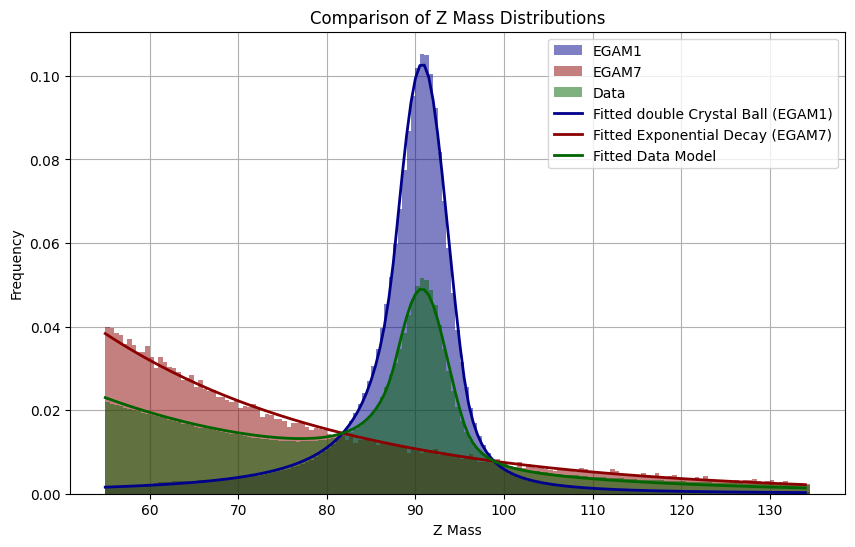

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data_egam1 / 1000, bins=bins, alpha=0.5, label="EGAM1", density=True, color="darkblue", zorder=2)
plt.hist(data_egam7 / 1000, bins=bins, alpha=0.5, label="EGAM7", density=True, color="darkred", zorder=2)
plt.hist(data_egamD / 1000, bins=bins, alpha=0.5, label="Data", density=True, color="darkgreen", zorder=2)

X = np.linspace(bins[0], bins[-1], 1000)
plt.plot(X, breit_wigner_crystal_ball(X, *vals_egam1), color="darkblue", label="Breit-Wigner convolved with Crystal Ball (EGAM1)", linewidth=1, zorder=10)
plt.plot(X, exponential_decay(X, *vals_egam7), color="darkred", label="Fitted Exponential Decay (EGAM7)", linewidth=1, zorder=10)
#plt.plot(X, data_fit_ratio(X, *vals_egamD_ratio), color="darkgreen", label="Fitted Data Model", linewidth=1, zorder=10)
plt.plot(X, true_data_fit(X, *vals_egamD_full), color="darkgreen", label="Fitted True Data Model", linewidth=1, zorder=10)
plt.xlabel("Z Mass")
plt.ylabel("Frequency")
plt.title("Comparison of Z Mass Distributions")
plt.legend()
plt.grid()
plt.show()

In [ ]:
Y_exp = exponential_decay(X, vals_egamD_full[1], vals_egamD_full[-1])
Y_peak = breit_wigner_crystal_ball(X, vals_egamD_full[0], vals_egamD_full[2], vals_egamD_full[3], vals_egamD_full[4], vals_egamD_full[5], vals_egamD_full[6])
exp_ratio = np.trapezoid(Y_exp, X)
peak_ratio = np.trapezoid(Y_peak, X)
plt.plot(X, Y_exp, color="orange", label="Exponential Decay Component", linewidth=1, zorder=10)
plt.plot(X, Y_peak, color="blue", label="Breit-Wigner convolved with Crystal Ball Component", linewidth=1, zorder=10)
print("Integral of Exponential Decay Component:", exp_ratio) 
print("Integral of Breit-Wigner convolved with Crystal Ball Component:", peak_ratio)

In [ ]:
MC_data = []
len_data = len(data_data[66.5 < data_data/1000][data_data[66.5 < data_data/1000]/1000 < 115.5])
while len(MC_data) < len_data:
    proposed_vals = np.random.uniform(66.5, 115.5, size=1000)
    acceptance_vals = np.random.random(1000)
    probabilities = true_data_fit(proposed_vals, *vals_data_full)
    accepted_vals = proposed_vals[acceptance_vals < probabilities*10]  # Scale probabilities to increase acceptance rate
    MC_data.extend(accepted_vals)

In [ ]:
bins = np.arange(66.5, 115.5, 0.1)
plt.hist(MC_data, bins=bins, alpha=0.5, label="Monte Carlo Data", color="purple", zorder=2)
plt.hist(data_data / 1000, bins=bins, alpha=0.5, label="Data", color="darkgreen", zorder=2)
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Comparison of Monte Carlo and Data")
plt.legend()
plt.show()

In [ ]:
vals_muon1, err_muon1, fval_muon1 = fit_function(
    data_muon1 / 1000,
    bins,
    breit_wigner_crystal_ball,
    initial_guess=[1.09716406, 91.1876, 2.98179821, 1.91401491, 1.16373524, 1.86966453],
    limits=bw_cb_limits,
)
vals_muonD_full, err_data, fval_data = fit_function(
    data_muonD / 1000,
    bins,
    true_data_fit,
    initial_guess=[1, 1, 91.1876, 2.4952, 2.5, 1.6, 1.5, 0.1]
    limits=data_fit_limits,
)

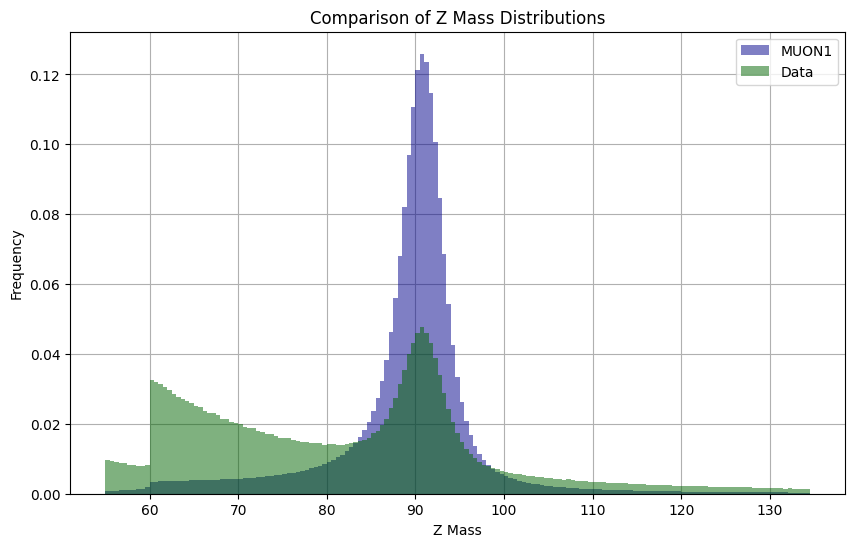

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data_muon1 / 1000, bins=bins, alpha=0.5, label="MUON1", density=True, color="darkblue", zorder=2)
plt.hist(data_muonD / 1000, bins=bins, alpha=0.5, label="Data", density=True, color="darkgreen", zorder=2)
plt.plot(X, breit_wigner_crystal_ball(X, *vals_muon1), color="darkblue", label="Breit-Wigner convolved with Crystal Ball (EGAM1)", linewidth=1, zorder=10)
plt.plot(X, true_data_fit(X, *vals_muonD_full), color="darkgreen", label="Fitted True Data Model", linewidth=1, zorder=10)
plt.xlabel("Z Mass")
plt.ylabel("Frequency")
plt.title("Comparison of Z Mass Distributions")
plt.legend()
plt.grid()

In [ ]:

electron_events = np.array([218019944, 9964151, 16232916]) #Number of events in EGAM1, EGAM7, and DataEgamma respectively.
electron_e2_events = np.array([len(data_egam1), len(data_egam7), len(data_data)]) #Number of events with 2 electrons in EGAM1, EGAM7, and DataEgamma respectively.
muon_events = np.array([288835800, 57192146])
ratios = electron_e2_events / electron_events
ratios

array([0.38865768, 0.04348138, 0.43423406])

In [ ]:
num_z_found = len(data_egamD)*vals_egamD_ratio[0]
num_z_estimated = num_z_found/ratios[0]

print(f"Number of found Z events in data: {int(num_z_found)}")
print(f"Estimated number of Z events in data: {int(num_z_estimated)}")

Number of found Z events in data: 2940660
Estimated number of Z events in data: 7566196


In [58]:
data = 36.1
cross_section = 1.981 * 1e6
electron_branch_ratio = 0.03363
expected = data * cross_section * electron_branch_ratio
expected

2405019.183

In [73]:
notebook_dir = Path.cwd()
h5_dirs_path = notebook_dir.parent / "h5"

# Choose two folders from the same particle type and simulation category.
source_1_dir = h5_dirs_path / "MC_EGAM1"
source_2_dir = h5_dirs_path / "MC_EGAM7"


def data_category(path):
    name = path.name.upper()
    particle = "MUONS" if "MUON" in name else "EGAM" if "EGAM" in name else None
    simulation = "DATA" if name.startswith("DATA_") else "MC" if name.startswith("MC_") else None
    if particle is None or simulation is None:
        raise ValueError(
            f"Cannot determine particle/simulation category from folder name: {path.name}"
        )
    return particle, simulation


if data_category(source_1_dir) != data_category(source_2_dir):
    raise ValueError(
        "Cannot mix folders with different particle types or categories: "
        f"{source_1_dir.name} and {source_2_dir.name}"
    )

h5_files_1 = sorted(
    path for path in source_1_dir.iterdir() if path.is_file() and path.suffix == ".h5"
)
h5_files_2 = sorted(
    path for path in source_2_dir.iterdir() if path.is_file() and path.suffix == ".h5"
)

if not h5_files_1:
    raise FileNotFoundError(f"No files found in {source_1_dir}")
if not h5_files_2:
    raise FileNotFoundError(f"No files found in {source_2_dir}")

print(f"Mixing {source_1_dir.name} with {source_2_dir.name}")

Mixing MC_EGAM1 with MC_EGAM7


In [75]:
import h5py
file = h5py.File(h5_files_1[0], 'r')
file["eventwise"][0]

np.void((1, 0, 353173148, 284500, 27.5, -1942.08), dtype=[('nEgammas', '<u8'), ('firstEgammaIndex', '<u8'), ('eventNumber', '<i8'), ('runNumber', '<u4'), ('averageInteractionsPerCrossing', '<f4'), ('mcEventWeight', '<f4')])

In [23]:
n_egammas = file["eventwise"]["nEgammas"]
indexes = file["eventwise"]["firstEgammaIndex"]

mask = np.array([0] * (indexes[-1] + n_egammas[-1]), dtype=bool)
for i in range(len(n_egammas)):
    if n_egammas[i] == 2:
        mask[indexes[i]:indexes[i] + 2] = True

origin = file["egammas"]["truthOrigin"][mask]
type_ = file["egammas"]["truthType"][mask]

ori_num = 13
type_num = 2
type_mask = (origin == ori_num) & (type_ == type_num)

pt = file["truth"]["pt"][mask][type_mask]
eta = file["truth"]["eta"][mask][type_mask]
phi = file["truth"]["phi"][mask][type_mask]

z_masses = []
for i in range(len(pt)//2):
    z_mass = np.sqrt(2 * pt[2*i] * pt[2*i + 1] * (np.cosh(eta[2*i] - eta[2*i + 1]) - np.cos(phi[2*i] - phi[2*i + 1])))
    z_masses.append(z_mass)

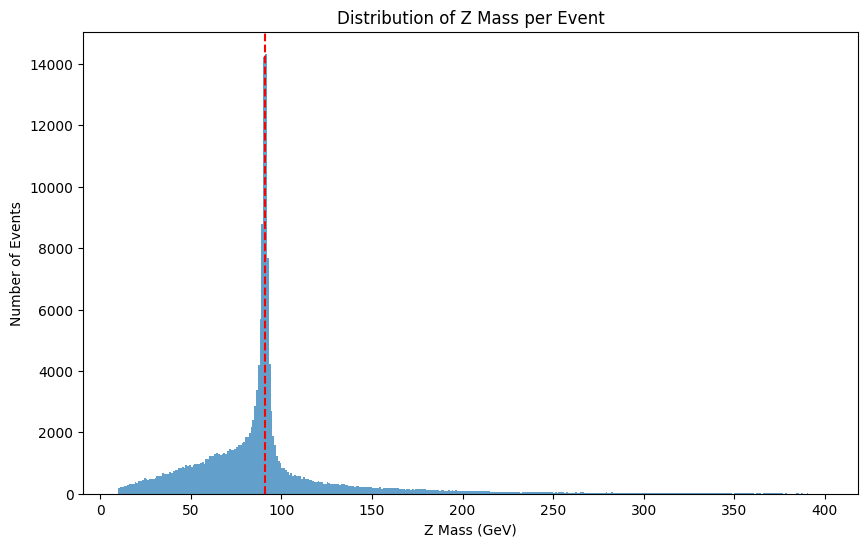

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(np.array(z_masses)/1000, bins=np.arange(10, 400, 1), alpha=0.7)
plt.axvline(x=91.180, color='r', linestyle='--')
plt.title("Distribution of Z Mass per Event")
plt.xlabel("Z Mass (GeV)")
plt.ylabel("Number of Events")
plt.show()

In [19]:
train_dataset = dataset_classes.H5EgammaDataset_fully_batched(
    h5_files_1[:5],
    exclude_features = ["truth"],
    exclude_fields = ["pt"],
    y_source = "truth",
    y_field = "pt",
)

mean, std = misc_functions.compute_mean_std(train_dataset, sample_size=100000, batch_size=4096)

val_dataset = dataset_classes.H5EgammaDataset_fully_batched(
    h5_files_1[5],
    exclude_features = ["truth"],
    exclude_fields = ["pt"],
    y_source = "truth",
    y_field = "pt",
)

train_sampler = data_loading.ShuffledContiguousBatchSampler(len(train_dataset), batch_size=4096)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=8, prefetch_factor=2, persistent_workers=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False, num_workers=8, prefetch_factor=2, persistent_workers=True, pin_memory=True)

model_pt = neural_models.NeuralNetwork(input_size=len(train_dataset.fields), hidden_sizes=[64, 64, 32, 16], output_size=1)
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)
loss_function = torch.nn.MSELoss()


model_pt, train_losses, val_losses, batch_losses = model_training.train_model(model_pt, optimizer, loss_function, train_loader, val_loader, num_epochs=5, device='cpu', log_target=True, means=mean, stds=std)

c:\Users\jonas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/5, Training Loss: 3.1703, Validation Loss: 1530294921.4917
Epoch 2/5, Training Loss: 0.1760, Validation Loss: 1530293519.3627
Epoch 3/5, Training Loss: 0.1499, Validation Loss: 1530294594.1235
Epoch 4/5, Training Loss: 0.1478, Validation Loss: 1530294912.6851
Epoch 5/5, Training Loss: 0.1299, Validation Loss: 1530314557.9668


In [20]:
torch.save(model_pt.state_dict(), "models_library/model_pt.pth")

In [12]:
import time

for workers in [2, 4, 6, 8]:
    for prefetch_factor in [2, 4, 6, 8]:
        loader = DataLoader(
            dataset,
            batch_sampler=sampler,
            num_workers=workers,
            prefetch_factor=prefetch_factor,
            persistent_workers=workers > 0,
            pin_memory=True,
        )

        start = time.perf_counter()

        for batch_number, (inputs, targets) in enumerate(loader):
            if batch_number == 5:
                start = time.perf_counter()  # Reset the timer after the first 5 batches
            if batch_number == 20:
                break

        elapsed = time.perf_counter() - start
        print(f"num_workers={workers}, prefetch_factor={prefetch_factor}: {elapsed:.2f} seconds")

num_workers=2, prefetch_factor=2: 25.46 seconds
num_workers=2, prefetch_factor=4: 21.88 seconds
num_workers=2, prefetch_factor=6: 26.84 seconds
num_workers=2, prefetch_factor=8: 25.10 seconds
num_workers=4, prefetch_factor=2: 15.24 seconds
num_workers=4, prefetch_factor=4: 17.70 seconds
num_workers=4, prefetch_factor=6: 15.57 seconds
num_workers=4, prefetch_factor=8: 18.21 seconds
num_workers=6, prefetch_factor=2: 14.45 seconds
num_workers=6, prefetch_factor=4: 12.23 seconds
num_workers=6, prefetch_factor=6: 16.79 seconds
num_workers=6, prefetch_factor=8: 15.54 seconds
num_workers=8, prefetch_factor=2: 9.84 seconds
num_workers=8, prefetch_factor=4: 15.94 seconds
num_workers=8, prefetch_factor=6: 13.87 seconds
num_workers=8, prefetch_factor=8: 11.48 seconds


In [66]:
325*15

4875